In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import joblib
from scipy.sparse import load_npz
import numpy as np


data = joblib.load('/Users/macbookair/Documents/NLP/Sentiment-analysis/data/alldata_tfidf_optimal.pkl')
x_train = data['x_train_tfidf_optimal']
x_test = data['x_test_tfidf_optimal']
y_train = data['y_train_enc']
y_test = data['y_test_enc']
tfidf = data['tfidf_optimal']
encoder = data['encoder']

/Users/macbookair/Documents/NLP/Sentiment-analysis/sensis-env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/macbookair/Documents/NLP/Sentiment-analysis/sensis-env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/macbookair/Documents/NLP/Sentiment-analysis/sensis-env/lib/python3.10/site-packages/sklearn/base.py:442: 

In [3]:
# ============================================
# SKENARIO C: Grid Search untuk Alpha
# ============================================
# Mencari alpha (smoothing parameter) terbaik

print("\n" + "="*60)
print("📌 SKENARIO C: Grid Search untuk Alpha (Smoothing)")
print("="*60)

# Definisikan nilai alpha yang akan dicoba
alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]



📌 SKENARIO C: Grid Search untuk Alpha (Smoothing)


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score


print(f"\n🔍 Mencari alpha terbaik dari: {alpha_values}")
print("-" * 40)

best_alpha = 1.0
best_score = 0
best_model = None
results_alpha = []

for alpha in alpha_values:
    mnb = MultinomialNB(alpha=alpha)
    mnb.fit(x_train, y_train)
    acc = mnb.score(x_test, y_test)
    results_alpha.append(acc)

    # Cross-validation score
    cv_mean = cross_val_score(mnb, x_train, y_train, cv=5).mean()

    print(f"   alpha={alpha:.3f}: Test Acc={acc:.4f} | CV Mean={cv_mean:.4f}")

    if acc > best_score:
        best_score = acc
        best_alpha = alpha
        best_model = mnb

print(f"\n✅ Alpha terbaik: {best_alpha} (Akurasi: {best_score:.4f})")


🔍 Mencari alpha terbaik dari: [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
----------------------------------------
   alpha=0.010: Test Acc=0.6171 | CV Mean=0.5586
   alpha=0.100: Test Acc=0.6171 | CV Mean=0.5813
   alpha=0.500: Test Acc=0.6253 | CV Mean=0.5964
   alpha=1.000: Test Acc=0.6281 | CV Mean=0.5944
   alpha=2.000: Test Acc=0.6253 | CV Mean=0.5992
   alpha=5.000: Test Acc=0.6116 | CV Mean=0.5999
   alpha=10.000: Test Acc=0.6061 | CV Mean=0.6040

✅ Alpha terbaik: 1.0 (Akurasi: 0.6281)


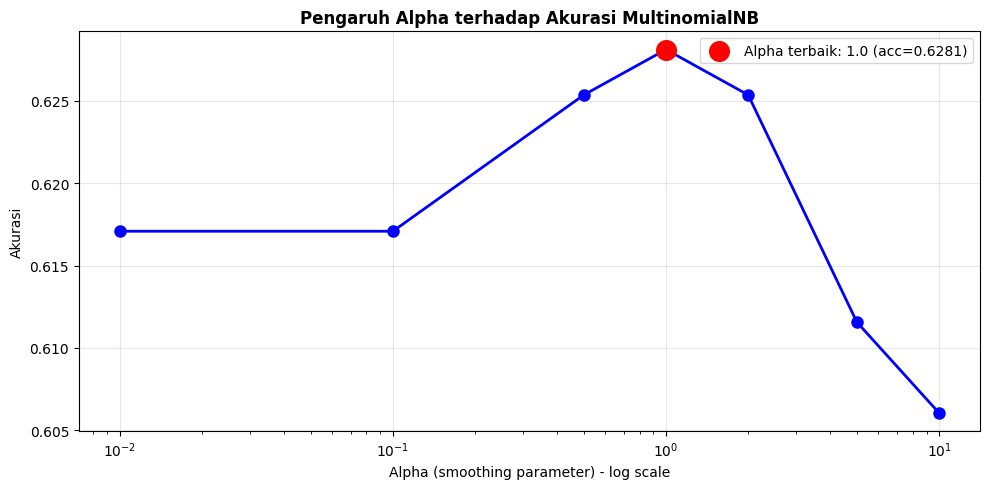

In [5]:
# ============================================
# VISUALISASI PENGARUH ALPHA
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
plt.plot(alpha_values, results_alpha, 'bo-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Alpha (smoothing parameter) - log scale')
plt.ylabel('Akurasi')
plt.title('Pengaruh Alpha terhadap Akurasi MultinomialNB', fontweight='bold')
plt.grid(True, alpha=0.3)

# Tandai alpha terbaik
plt.scatter([best_alpha], [best_score], color='red', s=200, zorder=5,
           label=f'Alpha terbaik: {best_alpha} (acc={best_score:.4f})')
plt.legend()

plt.tight_layout()
plt.savefig('percobaan7_alpha_optimization.png', dpi=150)
plt.show()

In [8]:
# Buat model terbaik (alpha=1.0 dari hasil grid search)
from sklearn.naive_bayes import MultinomialNB
best_model = MultinomialNB(alpha=1.0)
best_model.fit(x_train, y_train)

# Simpan model
import joblib
import os

save_dir = '/Users/macbookair/Documents/NLP/Sentiment-analysis/model_terbaik/'
os.makedirs(save_dir, exist_ok=True)

# Simpan semua komponen
model_package = {
    'model': best_model,
    'encoder': encoder,
    'tfidf': tfidf,
    'metadata': {
        'accuracy': 0.6281,
        'alpha': 1.0,
        'source_file': 'Percobaan_NB_3',
        'model_type': 'MultinomialNB'
    }
}

joblib.dump(model_package, f"{save_dir}best_naive_bayes_model.pkl")
print("✅ Model terbaik berhasil disimpan!")

✅ Model terbaik berhasil disimpan!
